# 1. EDA (20 min)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Overview

In [ ]:
data = pd.read_csv("data/restaurant_upgrade_conversion.csv")
data.head()

,customer_id,account_age_days,monthly_orders,avg_order_value,days_since_last_order,customer_ltv,app_engagement_score,num_favorites,review_count,used_scheduling,used_group_order,discount_pct,offer_duration_days,channel,offer_send_hour,offer_day_of_week,previous_offers_sent,previous_offers_accepted,converted
0,CUST_00000,430.862290,3,30.656103,7.037531,1320.855878,12.398973,3.0,0.0,0,0,10,30,in_app,5,1,3,0,0
1,CUST_00001,269.003651,8,17.573119,37.360624,1260.595489,111.223587,2.0,1.0,1,0,10,14,push,18,3,5,1,0
2,CUST_00002,248.811045,0,44.714054,64.645623,0.000000,14.653859,2.0,3.0,1,0,20,7,email,5,4,2,0,0
3,CUST_00003,248.814413,3,43.410614,22.121731,1080.118644,8.104749,1.0,0.0,0,0,30,14,sms,18,6,4,1,0
4,CUST_00004,836.948594,2,49.314915,14.638941,2751.603267,20.395211,3.0,2.0,0,0,20,14,email,8,5,2,1,0


In [4]:
data.shape

(5100, 19)

In [5]:
data.customer_id.nunique()

5000

In [6]:
# data[data.duplicated(["customer_id"])]
data[data.duplicated()]
# data.drop_duplicates([""])

,customer_id,account_age_days,monthly_orders,avg_order_value,days_since_last_order,customer_ltv,app_engagement_score,num_favorites,review_count,used_scheduling,used_group_order,discount_pct,offer_duration_days,channel,offer_send_hour,offer_day_of_week,previous_offers_sent,previous_offers_accepted,converted


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               5100 non-null   object 
 1   account_age_days          5100 non-null   float64
 2   monthly_orders            5100 non-null   int64  
 3   avg_order_value           5100 non-null   float64
 4   days_since_last_order     4740 non-null   float64
 5   customer_ltv              5100 non-null   float64
 6   app_engagement_score      5100 non-null   float64
 7   num_favorites             4898 non-null   float64
 8   review_count              4794 non-null   float64
 9   used_scheduling           5100 non-null   int64  
 10  used_group_order          5100 non-null   int64  
 11  discount_pct              5100 non-null   int64  
 12  offer_duration_days       5100 non-null   int64  
 13  channel                   5100 non-null   object 
 14  offer_se

- I notice 'used scheduling' and 'used group order' is int here, which is expected to be object.
- And also, we have small amount of missing values in some numerical features.

In [8]:
data[["used_scheduling", "used_group_order"]] = data[["used_scheduling", "used_group_order"]].astype("object")

- Next, let's check the descriptive statistics, it helps to spot obvious outliers and data quality issues.

In [9]:
# descriptive statistics of numerical features
data.describe()

,account_age_days,monthly_orders,avg_order_value,days_since_last_order,customer_ltv,app_engagement_score,num_favorites,review_count,discount_pct,offer_duration_days,offer_send_hour,offer_day_of_week,previous_offers_sent,previous_offers_accepted,converted
count,5100.000000,5100.000000,5100.000000,4740.000000,5100.000000,5100.000000,4898.000000,4794.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000
mean,362.635390,4.612157,39.786373,14.840993,3238.722904,29.942364,4.128420,2.011473,21.974510,17.540784,12.060196,3.006863,2.544314,0.434118,0.102745
std,253.001874,3.916035,25.526555,15.187370,12113.674631,19.921793,11.065995,1.403133,11.617698,8.761987,6.343389,1.995227,1.613521,0.800919,0.303655
min,4.004555,0.000000,4.183609,-28.000000,0.000000,0.300707,0.000000,0.000000,10.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,177.831434,2.000000,22.226625,4.318234,363.874182,16.241996,2.000000,1.000000,10.000000,14.000000,7.000000,1.000000,1.000000,0.000000,0.000000
50%,304.398023,4.000000,33.599114,10.431488,1062.862009,26.584131,3.000000,2.000000,20.000000,14.000000,11.000000,3.000000,2.000000,0.000000,0.000000
75%,485.027439,7.000000,50.140867,21.099114,2791.142566,39.418339,4.000000,3.000000,30.000000,30.000000,18.000000,5.000000,4.000000,1.000000,0.000000
max,2000.000000,35.000000,276.419321,145.741693,358777.170062,148.709970,147.000000,12.000000,50.000000,30.000000,23.000000,6.000000,10.000000,12.000000,1.000000


- I notice there are negative values in feature 'days_since_last_order', which should not be.
- And there are surprising max values in feature 'customer_ltv', 'account_age_days'.

- Next, I will look into distribution of our numerical features. 
- It can help us 1) identify data quality issues like outliers, 2) reveal customer behavior patterns, and 3) inform feature engineering decisions.

### View Data Distributions


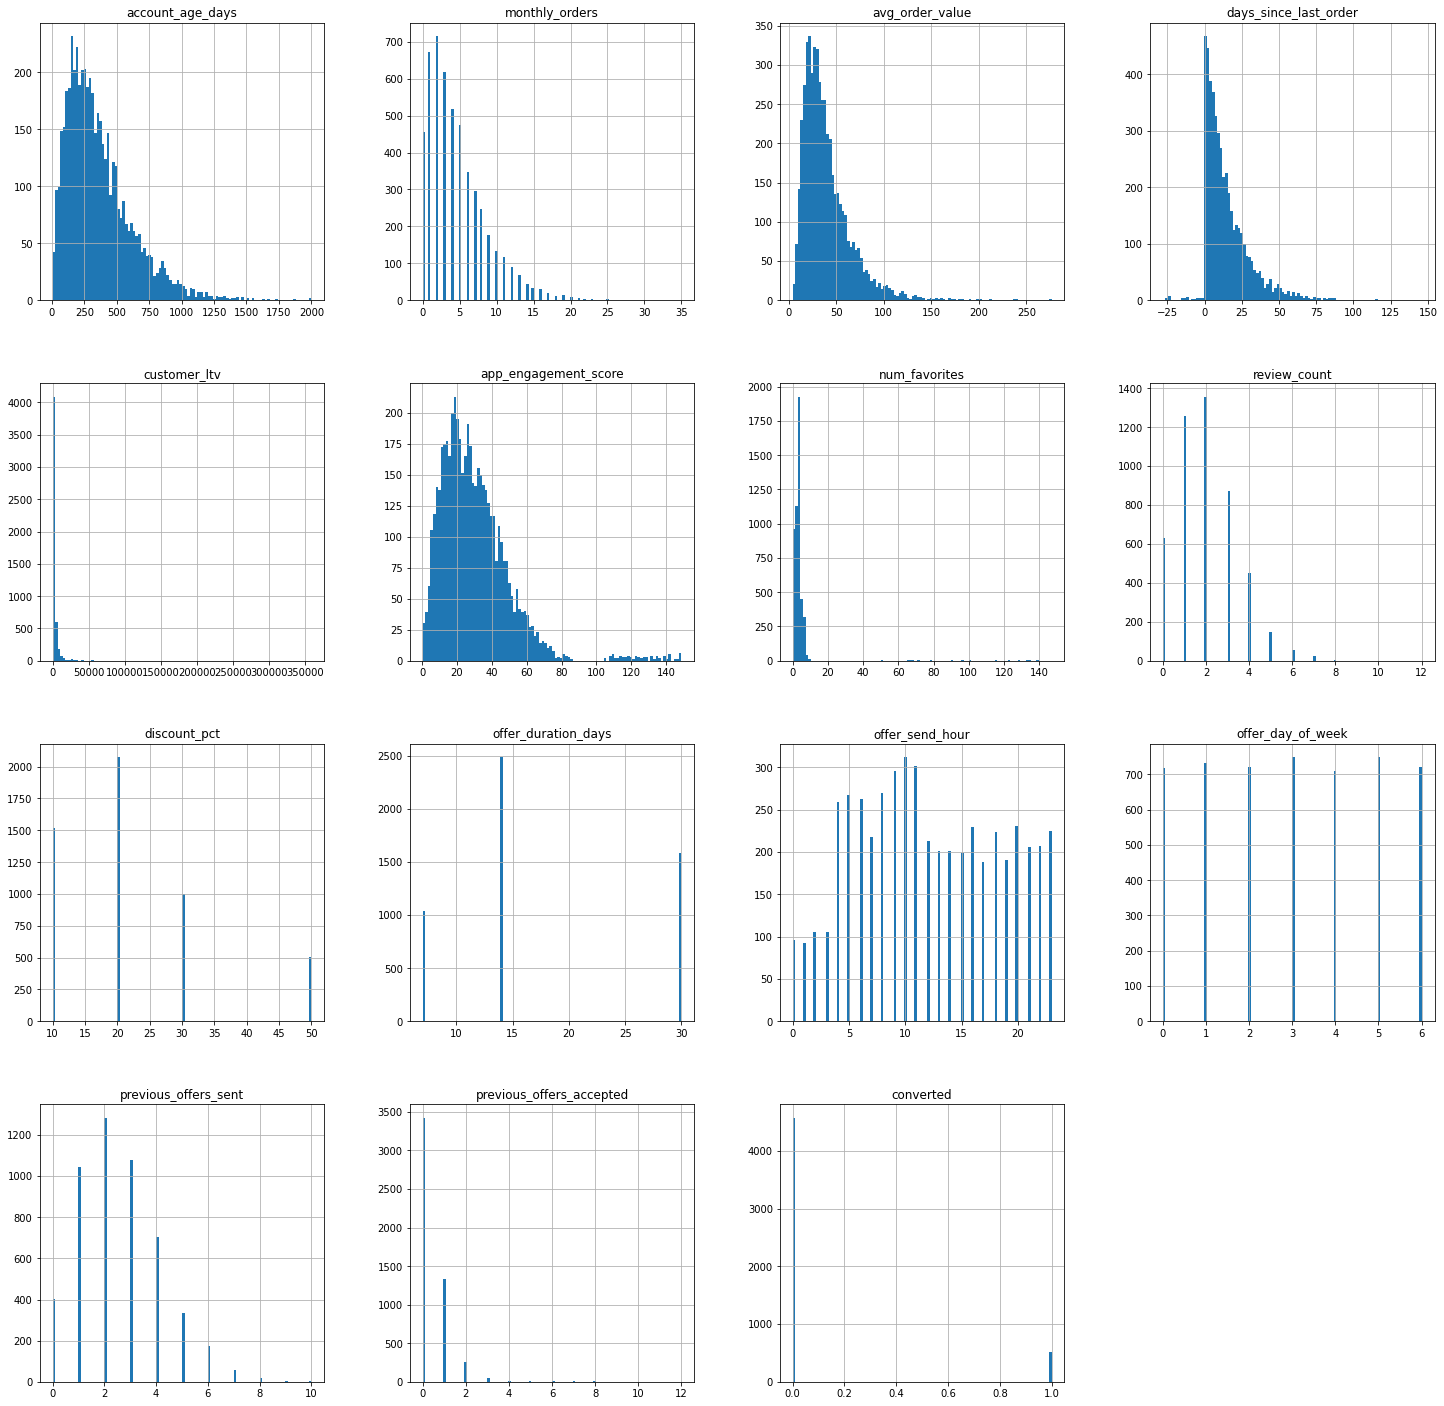

In [10]:
data.hist(figsize=(25, 25), bins=100);

Looking at the distributions, I can see some patterns:

- First, I noticed unexpected negative values in 'days_since_last_order', this is a data quality flag since days cannot be negative. It can be some calculation error, and I will need to handle these before proceeding. 

- And I also see outliers in multiple features like 'customer_ltv' and 'num_favorites'. These extreme values could represent genuine power customers or just data errors. -> Look at top 10 highest LTV customers, to see if other features like their past order #, account age days, average order numbers show consistent patterns like ltv.

- Second, I noticed some numerical features actually have discrete values, these would be better treated as categorical features, since it's not meaningful in the same way as continuous variables.

- Third, from business perspective, there is a clear pattern that most customers have low engagement, only a few customers have high engagement. This is typical for customer engagement platforms. I am thinking we should create engagement tiers - perhaps group customers by LTV brackets (low/ medium/ high value) and engagement levels (inactive/ casual/ power users). This would allow Braze to tailor campaigns differently for each segment rather than treating all customers all the same.

- Last, the conversion rate is very low, the data is highly imbalanced. We will need to up-sampling the minority samples and carefully choose the evaluation metrics.

Based on these insights, my next steps are:
- Address the data quality issue - handle negatives and validate outliers
- Reclassify discrete numerical features as categorical
- Create customer segment based on engagement and value 

### Handle Negative Values & Missing Values

In [11]:
data_cleaned = data.copy()

In [12]:
# Replace negative values of "days_since_last_order" as NaN
data_cleaned.loc[data_cleaned["days_since_last_order"] < 0, "days_since_last_order"] = np.nan

In [13]:
# Fill nan, impute right-skewed features with median values
features = ["days_since_last_order", "num_favorites", "review_count"]
data_cleaned[features] = data_cleaned[features].fillna(data_cleaned[features].median())

### Handle Outliers

In [14]:
# Clip outliers of "customer_ltv", "num_favorites"
from scipy.stats.mstats import winsorize
features = ["customer_ltv", "num_favorites"]
for feature in features:
    data_cleaned[feature] = winsorize(data_cleaned[feature], limits=[0.00, 0.05])

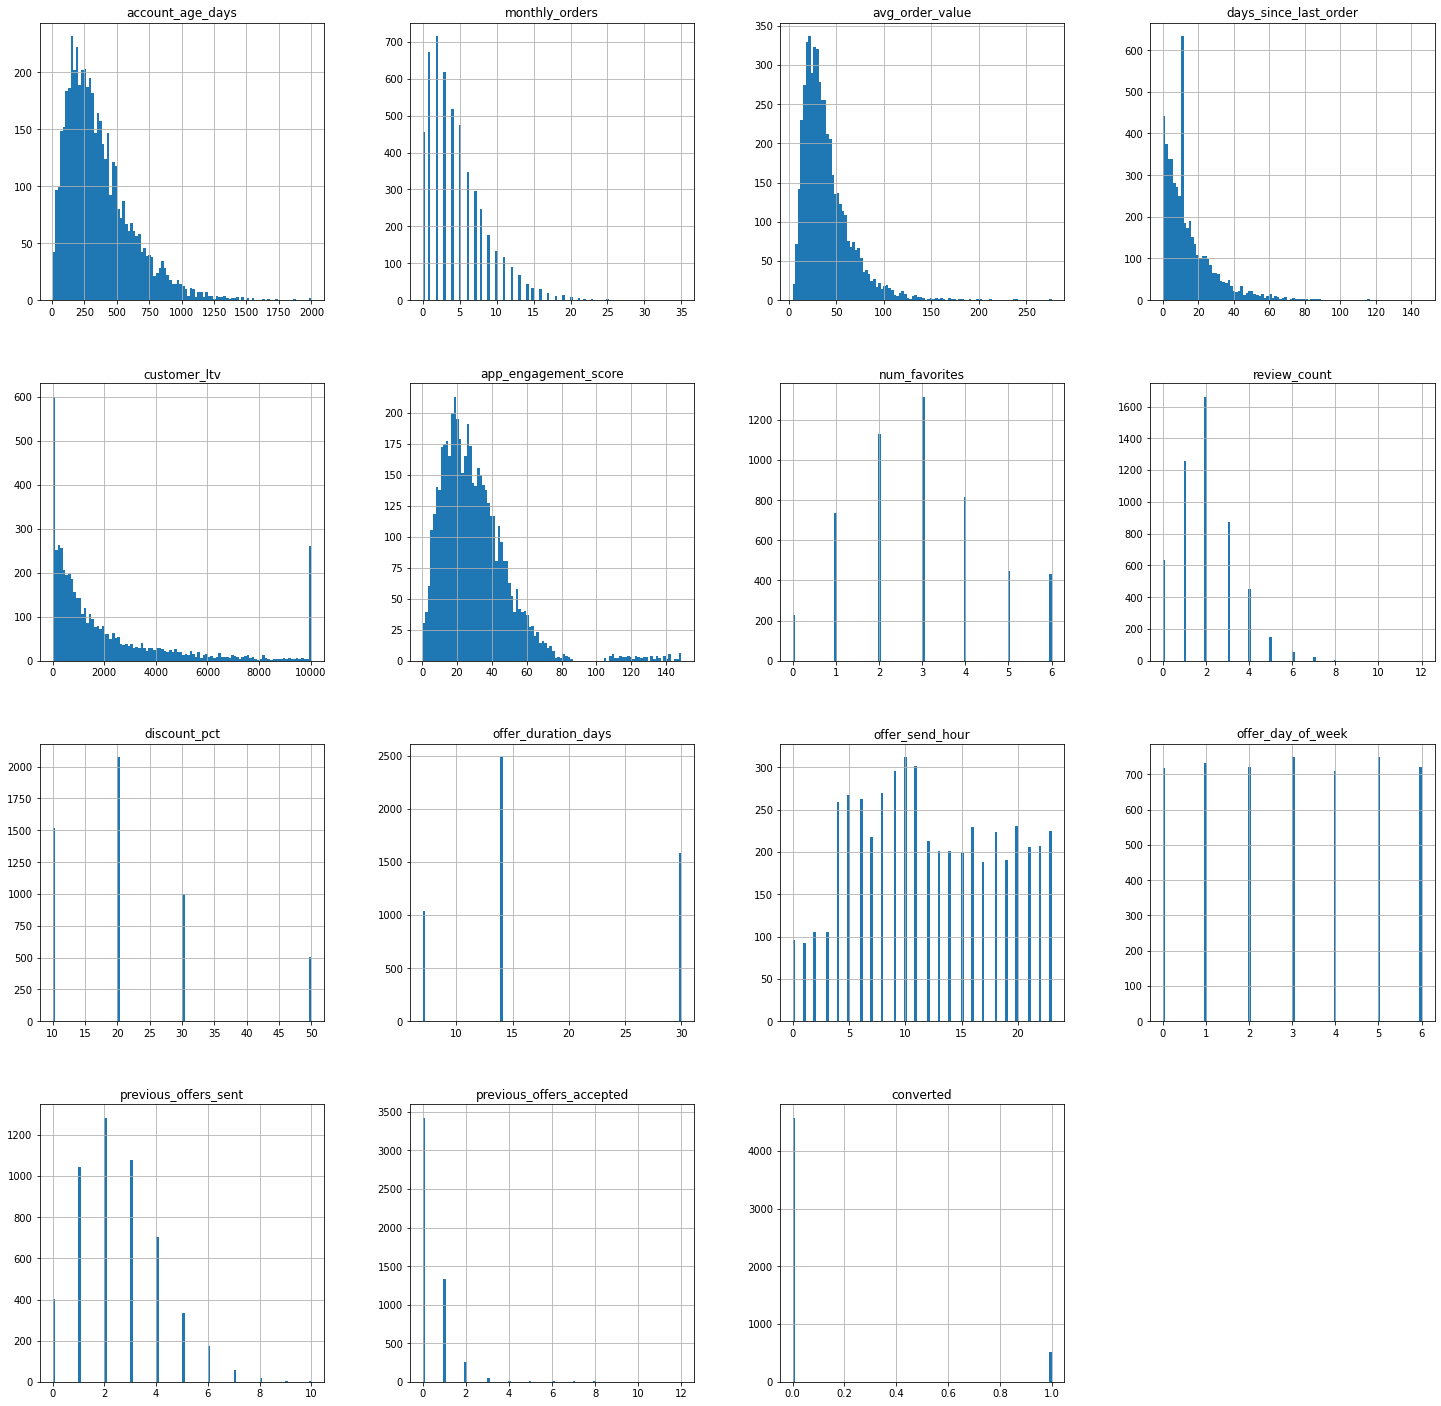

In [15]:
# data distribution after data cleaning
data_cleaned.hist(figsize=(25, 25), bins=100);

- We can see that after preprocessing, the negative values and outliers are well-handled.
- Although some numerical features are still right-skewed, log transform is not needed here, as I will use tree-based models that are scale-invariant.

- After have a overview of the data, and preprocess the numerical features, let's move on to the modeling part.
- In this part, I will first generate meaningful features out of the raw data, encode the categorical features, and then use Random Forest to make classification.

# 2. Modeling (20 min)

#### Feature Engineering (Enhanced Version)

In [16]:
# # Instead of treating individual hours/ days as numerical features, I will aggregate them into bins (night/ morning/ afternoon/ evening) & (weekend/ weekday)

# data_cleaned['is_weekend'] = data_cleaned['offer_day_of_week'].isin([5, 6])
# data_cleaned['time_of_day'] = pd.cut(
#     data_cleaned['offer_send_hour'], 
#     bins=[0, 6, 12, 18, 24], 
#     labels=['night', 'morning', 'afternoon', 'evening'])

# data_cleaned.head()

- Next, I will create LTV segments, converting continuous LTV into categorical segments. 
1. [Non-linearity] It helps capture non-linear relationships. Customer behavior often changes at thresholds. The difference between 50 dollars and 100 dollars might be small, while a 10K customer behaves fundamentally differently.
2. [Interpretability] It creates business-interpretable features. Stakeholders understand 'high/ medium/ low value customers' better than raw numbers.
3. [Interaction Terms] Make it easier to combine with other features.

In [17]:
# data_cleaned["customer_ltv_segment"] = pd.qcut(
#     data_cleaned["customer_ltv"], 
#     q=3, 
#     labels=["low", "medium", "high"], 
#     duplicates="drop") # handle duplicated bin edges

# data_cleaned['app_engagement_score_segment'] = pd.qcut(
#     data_cleaned['app_engagement_score'], 
#     q=3, 
#     labels=['Low', 'Medium', 'High'],
#     duplicates='drop')

#### Feature Encoding

- Random Forest does not handle categorical variables natively, so I will need to encode them numerically first.
- Here I choose one hot encoding, which is good for nominal features 

- `get_dummies()` converts categorical variables into dummy variables (one-hot encoding), this is especially useful when preparing data for machine learning algorithm that require numeric input.

In [18]:
# data_cleaned[["offer_send_hour", "offer_day_of_week"]] = data_cleaned[["offer_send_hour", "offer_day_of_week"]].astype("object") # nominal categorical feature
# data_cleaned = pd.get_dummies(data_cleaned, columns=["offer_send_hour", "offer_day_of_week", "channel"], drop_first=True)

# data_cleaned = pd.get_dummies(data_cleaned, columns=["channel", "is_weekend", "time_of_day", "customer_ltv_segment", "app_engagement_score_segment"], drop_first=True)

data_cleaned = pd.get_dummies(data_cleaned, columns=["channel"], drop_first=True)
data_cleaned.head()

,customer_id,account_age_days,monthly_orders,avg_order_value,days_since_last_order,customer_ltv,app_engagement_score,num_favorites,review_count,used_scheduling,...,discount_pct,offer_duration_days,offer_send_hour,offer_day_of_week,previous_offers_sent,previous_offers_accepted,converted,channel_in_app,channel_push,channel_sms
0,CUST_00000,430.862290,3,30.656103,7.037531,1320.855878,12.398973,3.0,0.0,0,...,10,30,5,1,3,0,0,True,False,False
1,CUST_00001,269.003651,8,17.573119,37.360624,1260.595489,111.223587,2.0,1.0,1,...,10,14,18,3,5,1,0,False,True,False
2,CUST_00002,248.811045,0,44.714054,64.645623,0.000000,14.653859,2.0,3.0,1,...,20,7,5,4,2,0,0,False,False,False
3,CUST_00003,248.814413,3,43.410614,22.121731,1080.118644,8.104749,1.0,0.0,0,...,30,14,18,6,4,1,0,False,False,True
4,CUST_00004,836.948594,2,49.314915,14.638941,2751.603267,20.395211,3.0,2.0,0,...,20,14,8,5,2,1,0,False,False,False


#### Data Split

In [19]:
from sklearn.model_selection import train_test_split

X = data_cleaned.copy().drop(columns=["customer_id", "converted"])
y = data_cleaned["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(4080, 19) (1020, 19)


In [20]:
print(y_train.mean(), y_test.mean())

0.10269607843137254 0.10294117647058823


- `stratify` ensures train and test sets have the same proportion of each class in target variable 
- It prevents senarios where test set is much harder/ easier than training set

#### Upsampling with SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

X_train_balanced, y_train_balanced = SMOTE().fit_resample(X=X_train, y=y_train)

print(X_train.shape, y_train.shape)
print(X_train_balanced.shape, y_train_balanced.shape)

(4080, 19) (4080,)
(7322, 19) (7322,)


- Synthetic Minority Over-sampling Technique (`SMOTE`)
- SMOTE uses k-nearest neighbors interpolation to generate synthetic samples between existing minority class examples
- Steps: 
1) for each minority class sample, find its k nearest neighbors (k=5) from the same minority class, use Euclidean distance in feature space
2) Randomly select one of those k neighbors
3) Create synthetic sample along the line between them: synthetic sample = original + λ × (neighbor - original), where λ is a random number between 0 and 1
- Only apply to training set, never test set
- Not always necessary, try class weights first: class_wieght='balanced' in most sklearn models

#### Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the whole dataset is used to build
each tree.

Read more in the :ref:`User Guide <forest>`.

Parameters
----------
n_estimators : int, default=100
    The number of trees in the forest.


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200, # more trees = better performance 
    max_depth=None, # allow trees to grow deep (or 15-20)
    min_samples_split=5, # prevent overfitting
    min_samples_leaf=2, # prevent overfitting
    random_state=40, # reproducibility
    class_weight='balanced', # handle imbalance
    n_jobs=-1 # use all CPU cores
)
rf_model = rf_model.fit(X_train, y_train)
rf_model

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=40)

`class_weight = balanced`
- If 90% negative, 10% positive -> positive class gets 9* weight
- Each tree's loss function penalizes minority class more heavily -> When calculating Gini impurity or entropy, minority class count more
- Gini Impurity = 1 - Σ(p_i)²

### Random Forest Parameter GridSearch (Enhanced Version)

In [24]:
# from sklearn.model_selection import GridSearchCV

# # total combinations: 3 * 4 * 3 * 3
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(
#     estimator=rf_model, # model
#     param_grid=param_grid, 
#     cv=5, # 5-fold cross validation
#     scoring='f1', # evaluation metric (accuracy, f1, roc_auc)
#     n_jobs=-1, # parallel processing
#     # verbose=2, # print progress (0=silent, 1=some, 2=detailed)
#     # refit=True
#     )

# # for each combination, perform k-fold cross validation
# # split training data into 5 folds, get score (f1) on 5 validation sets
# # compare all combinations, and get the best model

# grid_search.fit(X_train, y_train)

In [25]:
# best_model = grid_search.best_estimator_
# best_score = grid_search.best_score_
# results_df = pd.DataFrame(grid_search.cv_results_)

In [26]:
# best_model

- `GridSearchCV` performs exhaustive search over hyperparameter combinations using cross-validation

#### Evaluate on Test Set

In [27]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [28]:
# roc -> recall, precision, avg precision, f1
from sklearn.metrics import recall_score, precision_score, average_precision_score
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(recall, precision)

0.05714285714285714 0.6


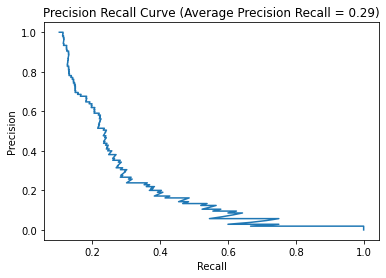

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
average_precision_recall = average_precision_score(y_test, y_pred_proba)
plt.plot(precision, recall);
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision Recall Curve (Average Precision Recall = {round(average_precision_recall, 2)})");

# 3. Feature Importance (10 min)

In [30]:
feature_importance = rf_model.feature_importances_
feature_importance

array([0.09377174, 0.09833972, 0.0840616 , 0.09877694, 0.11591635,
       0.10245952, 0.04407163, 0.03629866, 0.01989733, 0.01343768,
       0.05993734, 0.02641205, 0.06138681, 0.04311866, 0.04028243,
       0.03330386, 0.00785531, 0.01172639, 0.00894598])

In [31]:
feature_names = X_train.columns.tolist()
feature_importance_df = pd.DataFrame({"features": feature_names, "feature_importance": feature_importance})
feature_importance_df = feature_importance_df.sort_values("feature_importance", ascending=False)
feature_importance_df

,features,feature_importance
4,customer_ltv,0.115916
5,app_engagement_score,0.102460
3,days_since_last_order,0.098777
1,monthly_orders,0.098340
0,account_age_days,0.093772
2,avg_order_value,0.084062
12,offer_send_hour,0.061387
10,discount_pct,0.059937
6,num_favorites,0.044072
13,offer_day_of_week,0.043119


<Axes: xlabel='feature_importance', ylabel='features'>

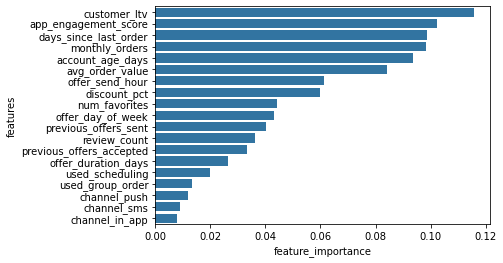

In [32]:
sns.barplot(data=feature_importance_df.head(25), x="feature_importance", y="features")

`Conclusions`
1. discount_pct is by far the most important feature (~0.18) - discount level dominates conversion prediction
2. Behavioral features matter: used_scheduling, num_favorites, and customer engagement metrics (customer_ltv, monthly_orders) are strong predictors
3. offer_duration_days is moderately important (~0.08) - duration matters but less than discount
4. Channel and timing features are weak:
- Individual day_of_week and send_hour categories have very low importance (<0.01)
- Suggests when and how offers are sent matters much less than what is offered
5. One-hot encoding created noise: Multiple weak dummy variables (offer_day_of_week_X, offer_send_hour_X) clutter the bottom - these nominal features have minimal predictive power

Key insight: Focus optimization efforts on discount strategy and targeting high-engagement customers rather than timing/channel optimization.Claude is AI and can make mistakes. Please double-check responses. Sonnet 4.5

`Feature Importance of Random Forest`
- Core Mechanism: For each feature, RF tracks how much it reduces impurity (Gini or Entropy) across all trees.

1. During tree construction, when a tree splits on a feature at a node: 
   
   eg. parent node impurity = 0.5, left child impurity = 0.3 (500 samples), right child impurity = 0.2 (500 samples) -> weighted child impurity = (500 * 0.3 + 500 * 0.2) / (500 + 500) = 0.25 -> impurity decreases: 0.5 - 0.25 = 0.25 (this feature gets + 0.25 importance)

2. For each feature, sum up impurity decrease every time it's used to split (across all nodes in all trees)
3. Normalize: feature importance normalized = feature importance / sum(all feature importance)

- High importance <-> feature make good splits: reduces impurity significantly when used + used frequently across many trees + helps separate classes effectively

`Important Caveats`
- Biased toward high-cardinality features:
1. [unique values] features with more unique values get more splitting opportunities
2. [continuous vs. binary variables] continuous features often appear more important than binary features, not because they are truly more predictive, but more splitting options
3. [no direction] does not indicate direction: high importance does not tell you if feature increases or decreases target, just say it's useful for prediction

In [33]:
# ### Alternative: Permutation Importance, more reliable but slower
# from sklearn.inspection import permutation_importance

# # After training:
# perm_importance = permutation_importance(
#     rf_model, 
#     X_test, 
#     y_test, 
#     n_repeats=10, 
#     random_state=42
# )

# # How it works:
# # 1. Get baseline accuracy on test set
# # 2. Shuffle feature 'discount_pct' → recalculate accuracy
# # 3. Importance = baseline_accuracy - shuffled_accuracy
# # 4. Repeat for all features

In [34]:
# perm_importance_df = pd.DataFrame({
#     'feature': X_test.columns,
#     'importance_mean': perm_importance.importances_mean,
#     'importance_std': perm_importance.importances_std
# }).sort_values('importance_mean', ascending=False)
# perm_importance_df

In [35]:
# plt.barh(
#     perm_importance_df['feature'][:15],  # Top 15 features
#     perm_importance_df['importance_mean'][:15],
#     xerr=perm_importance_df['importance_std'][:15],  # Error bars show variability
#     color='steelblue',
#     alpha=0.8
# )

# 4. Next Steps (10 min)
  
- Feature Engineering: Add more meaningful features
- Tune Model Parameter using Cross Validation: GridSearch(): exhaustive search over hyperparameter combinations using cross-validation
- Alternative Model: Boosting Method
- Alternative Feature Importance Measure: Permutation 

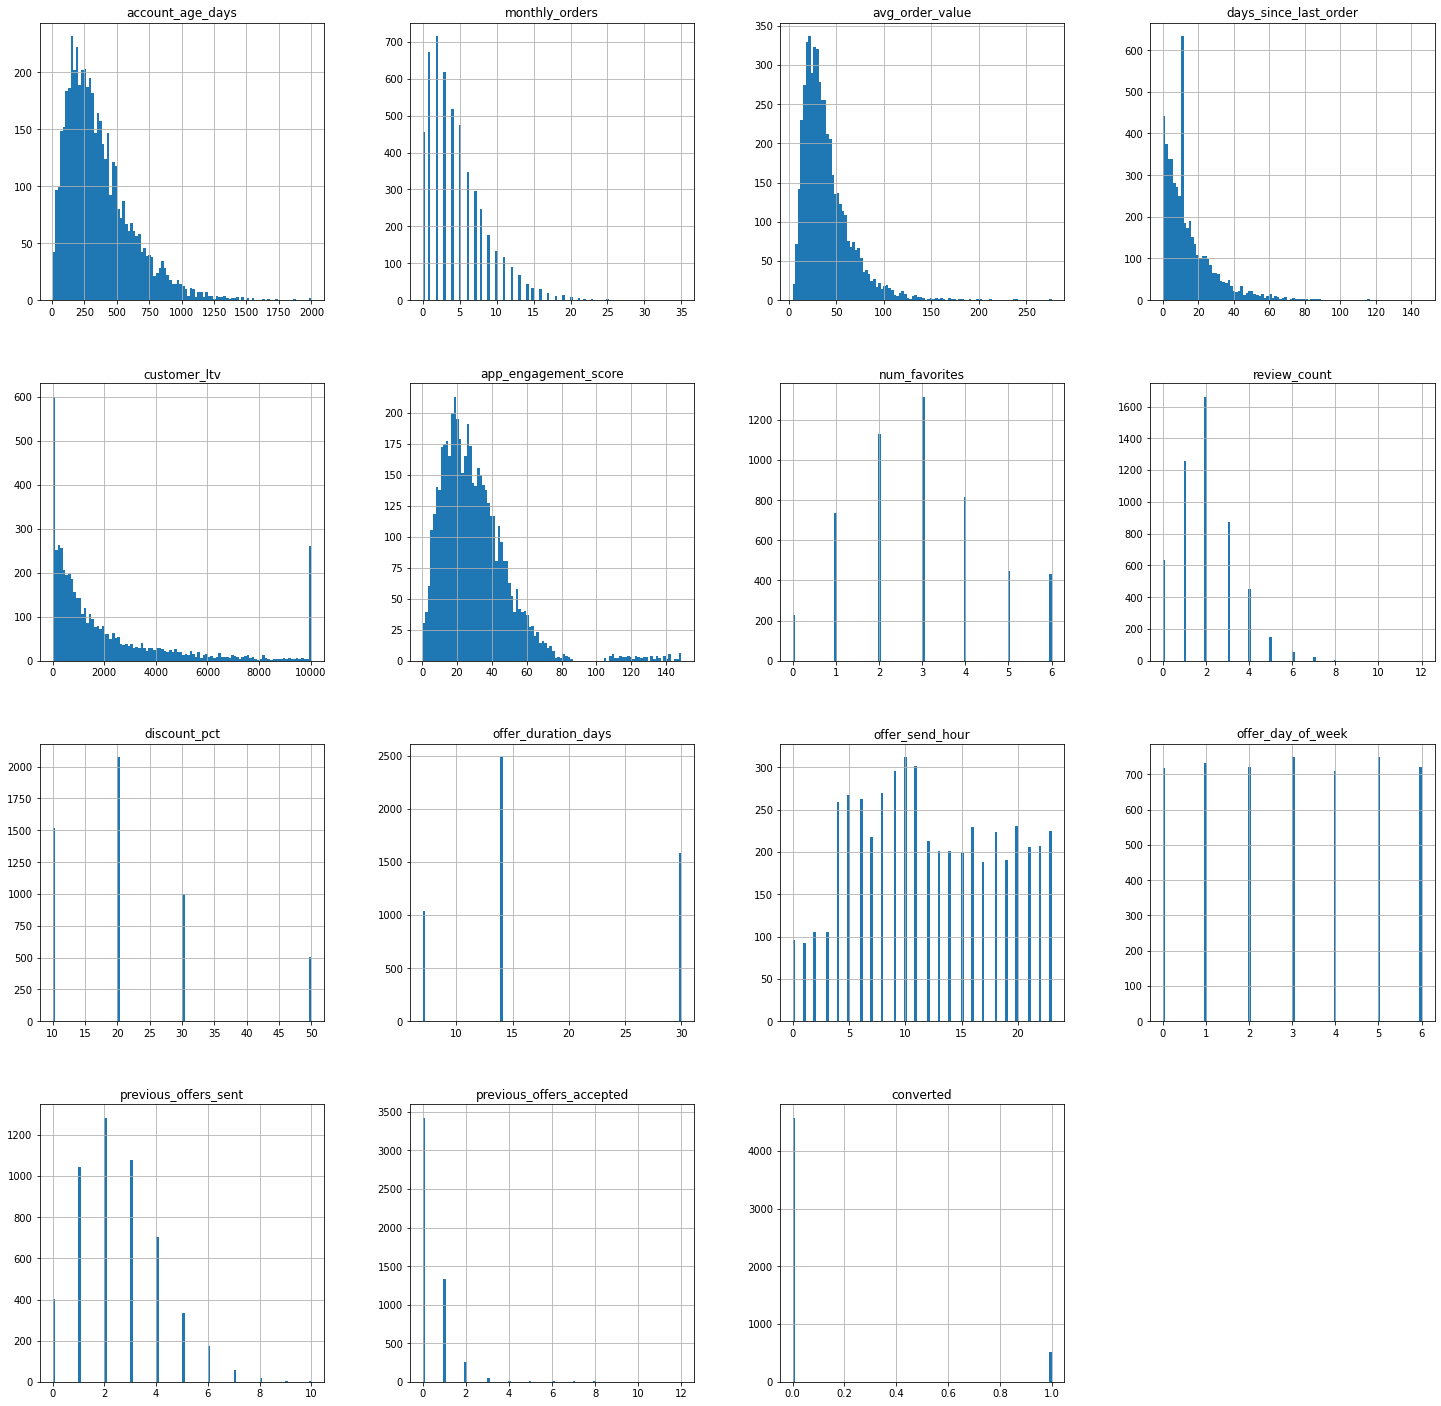

In [42]:
# plot hist of data
data_cleaned.hist(figsize=(25, 25), bins=100);